## Question 4

### **Stellar Spectrum Reduction**

In [1]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

*Veloce is a high-resolution echelle spectrograph. The flat.fits and moon.fits in data/ contain the same 4112 × 385 pixel detector region around the Ca II triplet (∼ 851–871 nm).*

*The dispersion direction is vertical and the cross-dispersion direction horizontal. The central science fibres are bounded by two low-illumination gaps; the curves following these gaps are the tramlines. Signal from neighbouring spectral orders has been set to zero. You may assume that the distance between the two tramlines is constant.*

1.

*Use the flat-field image to determine the tramline positions as a function of dispersion
pixel and fit an appropriate smooth function. Briefly explain your approach and plot the
flat with your fitted tramlines overlaid.*

*Hints: Each row of the image is a cross-dispersion profile. No particular fitting method
or polynomial order is required; motivate and use a reasonable method.*

In [2]:
flat = fits.open('data/flat.fits')[0].data
moon = fits.open('data/moon.fits')[0].data

n_disp, n_xdisp = flat.shape
y_pix = np.arange(n_disp)
x_pix = np.arange(n_xdisp)

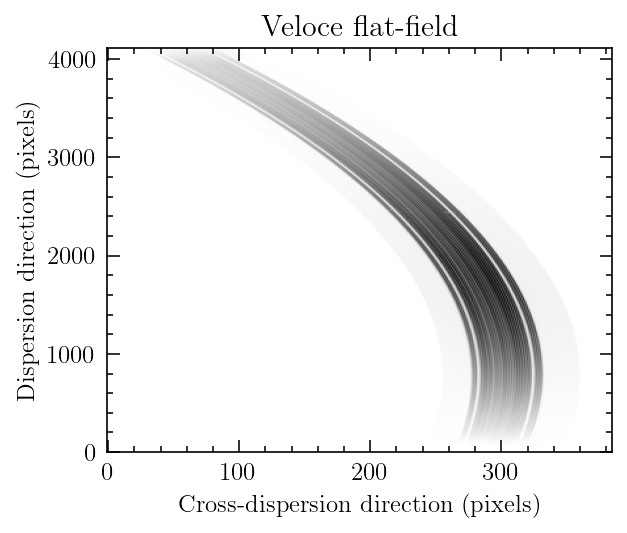

In [3]:
plt.imshow(flat, cmap='gray_r', origin='lower')
plt.gca().set_aspect(0.075)
plt.title('Veloce flat-field')
plt.xlabel('Cross-dispersion direction (pixels)')
plt.ylabel('Dispersion direction (pixels)')
plt.show()

The method I chose to find the tramline minima was to take the derivative of each row by comparing the counts in adjacent pixels. The tramline regions would therefore be found near where the derivative was greatest (greatest difference from low-illumination to high-illumination regions).

The expected distance between the two tramlines is 41-42 pixels, so we can parse this in as an argument to the find_peaks function. During testing, I found that the right tramline would almost always be correctly identified, however there were some issues with finding the left tramline (due to the other large derivative further to the left): for those rare cases (less than 10%), I decided to automatically determine the left tramline value by offsetting the correctly determined right tramline either 41 or 42 pixels.

Additionally, we only use rows with sufficient signal (maximum row signals >5% of the maximum flat field count), to avoid noisy low-illumination rows.

In [4]:
def find_peaks_in_row(row_index):
    if flat[row_index, :].max() < 0.05 * flat.max():
        return np.array([np.nan, np.nan])
    dx = np.roll(flat[row_index, :], -1) - flat[row_index, :]
    peaks, properties = find_peaks(dx,
        distance=40,       # fixed distance between tramlines
        prominence=np.max(dx)*0.75)
    
    if len(peaks) == 2:
        if peaks[1]-peaks[0] > 43:
            peaks[0] = peaks[1]-np.random.randint(41,42)
    return peaks-1 # minima occurs at previous pixel

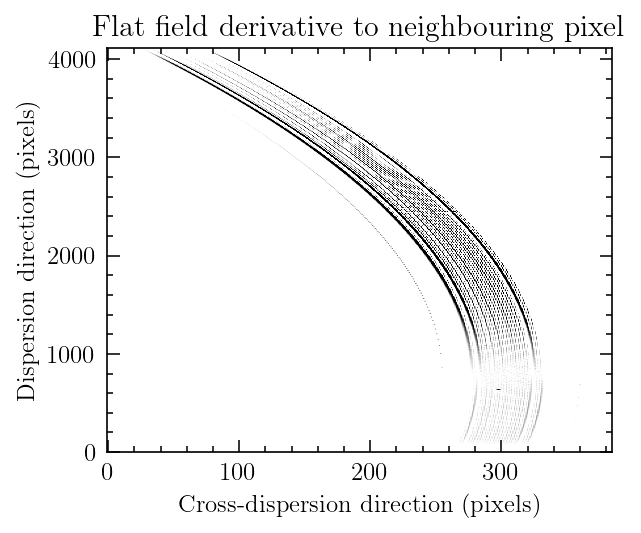

In [5]:
plt.imshow(np.roll(flat, -1, axis=0)-flat, cmap='gray_r', origin='lower', vmin=10, vmax=150)
plt.gca().set_aspect(0.075)
plt.title('Flat field derivative to neighbouring pixel')
plt.xlabel('Cross-dispersion direction (pixels)')
plt.ylabel('Dispersion direction (pixels)')
plt.show()

4279860154.py: Candidate gap positions: [282 323]


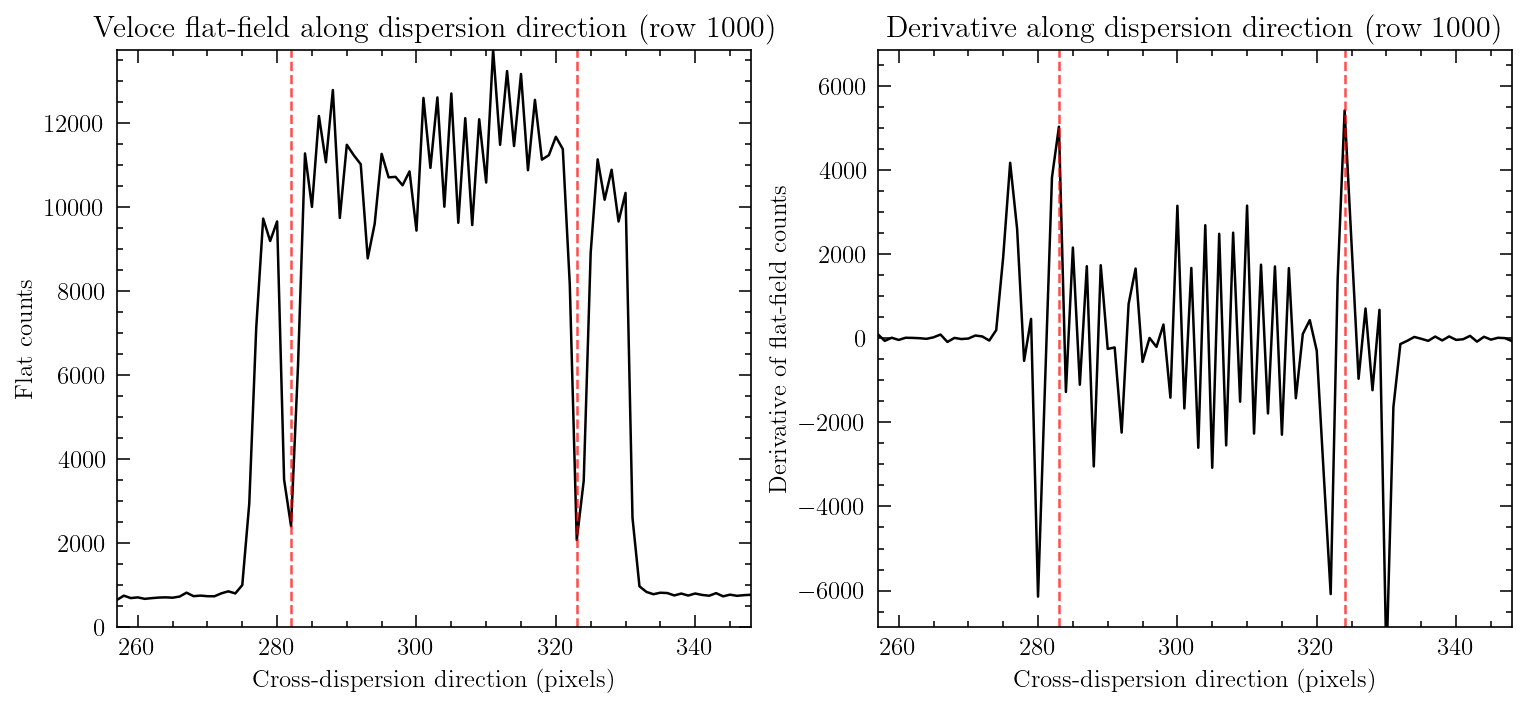

In [6]:
i = 1000
peaks = find_peaks_in_row(i)
print("Candidate gap positions:", peaks)

# two plots, one with the flat counts and the other with the derivative of the flat counts
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

ax[0].plot(flat[i, :], color='black')
for peak in peaks:
    ax[0].axvline(peak, color='red', linestyle='--', alpha=0.7)

ax[0].set_xlabel('Cross-dispersion direction (pixels)')
ax[0].set_ylabel('Flat counts')
ax[0].set_title(f'Veloce flat-field along dispersion direction (row {i})')
ax[0].set_xlim(peaks[0]-25, peaks[1]+25)
ax[0].set_ylim(0, flat[i, :].max())

ax[1].plot(np.roll(flat[i, :], -1) - flat[i, :], color='black')
for peak in peaks:
    ax[1].axvline(peak+1, color='red', linestyle='--', alpha=0.7)

ax[1].set_xlabel('Cross-dispersion direction (pixels)')
ax[1].set_ylabel('Derivative of flat-field counts')
ax[1].set_title(f'Derivative along dispersion direction (row {i})')
ax[1].set_xlim(peaks[0]-25, peaks[1]+25)
ax[1].set_ylim(-flat[i, :].max()/2, flat[i, :].max()/2)

fig.show()

In [7]:
left = np.full(n_disp, np.nan)
right = np.full(n_disp, np.nan)
for k in range(n_disp):
    peaks = find_peaks_in_row(k)
    if len(peaks) == 2:
        left[k] = peaks[0]
        right[k] = peaks[1]

valid = np.isfinite(left) & np.isfinite(right)
sep = np.nanmedian(right[valid] - left[valid])+1

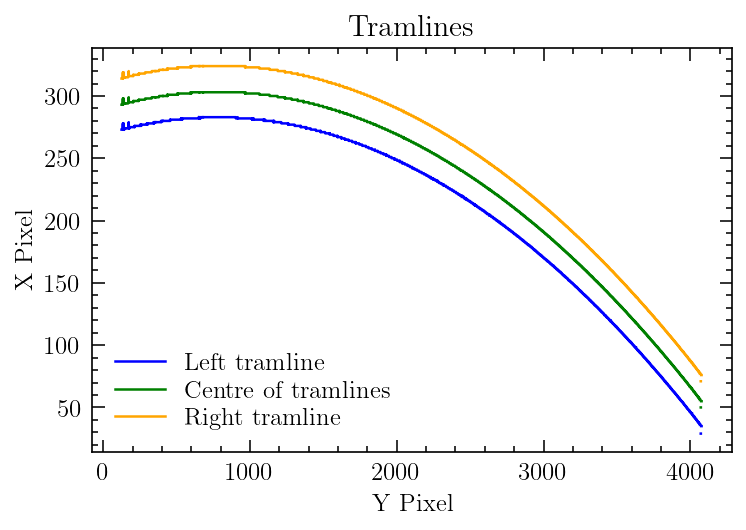

In [8]:
plt.plot(y_pix, left, color='blue', label='Left tramline')
plt.plot(y_pix, right-sep/2, color='green', label='Centre of tramlines')
plt.plot(y_pix, right, color='orange', label='Right tramline')
plt.xlabel('Y Pixel')
plt.ylabel('X Pixel')
plt.title('Tramlines')
plt.legend(loc='lower left')
plt.show()

Because the tramline separation is constant (~42 pixels), we can fit a single smooth polynomial to the centre of the two tramlines, and then reconstruct the two tramlines with f(y) +/- 21 pixels, reducing the effect of noise. A third degree polynomial seems sufficient in this case, as the overall shape of the tramlines appears to be roughly quadratic - additionally, the coefficient of the y^3 term is 1e-6 times smaller than that of the y^2 term, so it essentially negligible.

3069931819.py: Polynomial coefficients (order 3): [-1.17428010e-11 -2.26753191e-05  3.51981368e-02  2.89863998e+02]


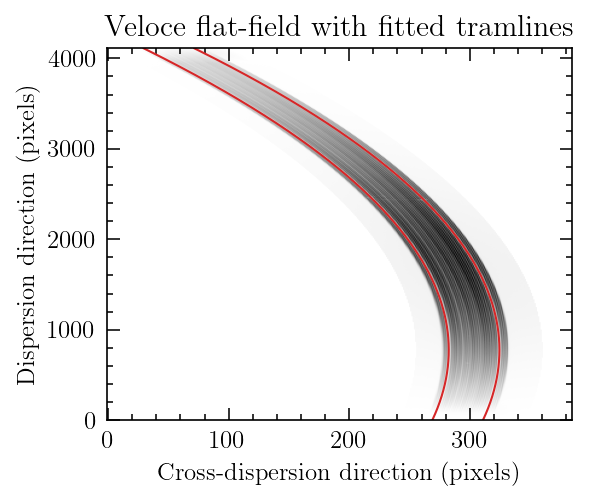

In [55]:
centre = (left + right) / 2
poly_order = 3
coeffs = np.polyfit(y_pix[valid], centre[valid], poly_order)
print(f"Polynomial coefficients (order {poly_order}): {coeffs}")
centre_fit = np.polyval(coeffs, y_pix)

left_fit = centre_fit - sep/2
right_fit = centre_fit + sep/2

plt.imshow(flat, cmap='gray_r', origin='lower')
plt.plot(left_fit, y_pix, color="tab:red", lw=1)
plt.plot(right_fit, y_pix, color="tab:red", lw=1)
plt.gca().set_aspect(0.075)
plt.title('Veloce flat-field with fitted tramlines')
plt.xlabel('Cross-dispersion direction (pixels)')
plt.ylabel('Dispersion direction (pixels)')
plt.tight_layout()
plt.savefig("figures/tramlines_overlay.pdf", dpi=300)
plt.show()

2.

*Sum the counts between your tramlines to extract the flat-field and Moon spectra. Divide
Moon by flat and plot the result as a function of dispersion pixel.*

*Identify and indicate
the pixels corresponding to the Ca II lines at 8498, 8542, and 8662 ˚A.*

In [10]:
flat_spec = np.zeros(n_disp)
moon_spec = np.zeros(n_disp)

for y in range(n_disp):
    x_left = int(left_fit[y])
    x_right = int(right_fit[y])
    flat_spec[y] = np.sum(flat[y, x_left:x_right])
    moon_spec[y] = np.sum(moon[y, x_left:x_right])

ratio = moon_spec / flat_spec
ratio[~np.isfinite(ratio)] = np.nan

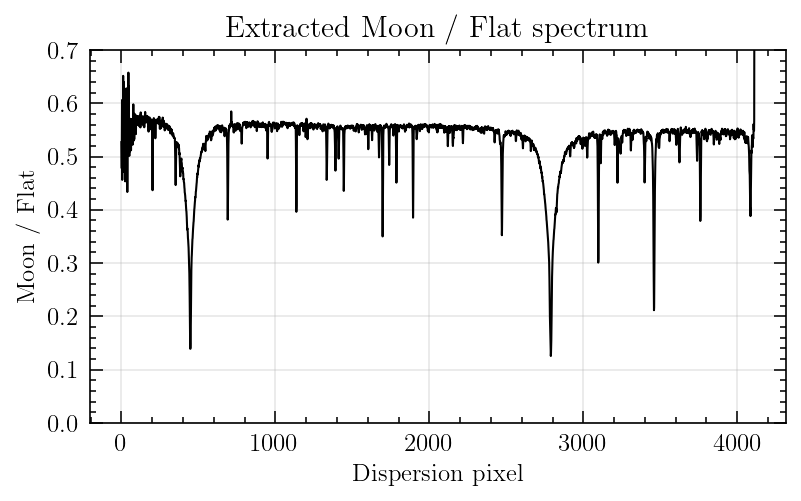

In [12]:
plt.plot(y_pix, ratio, lw=1, color='black')
plt.xlabel("Dispersion pixel")
plt.ylabel("Moon / Flat")
plt.title("Extracted Moon / Flat spectrum")
plt.ylim(0, 0.7)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/moon_flat_ratio.pdf", dpi=300)
plt.show()

To identify the Ca II spectral lines at 8498, 8542 and 8662 Angstroms, we first smooth the ratio to eliminate narrow lines, then we identify the peaks corresponding to the three strongest lines - the third peak is expected to be around 75% of the intensity of the other two peaks [A&A 535, A106 (2011)].

In [21]:
ratio_smooth = gaussian_filter1d(ratio, sigma=5)
ratio_smooth2 = -ratio_smooth + np.median(ratio_smooth)

3556800347.py: Identified peaks (pixels): [ 447 2789 3459]


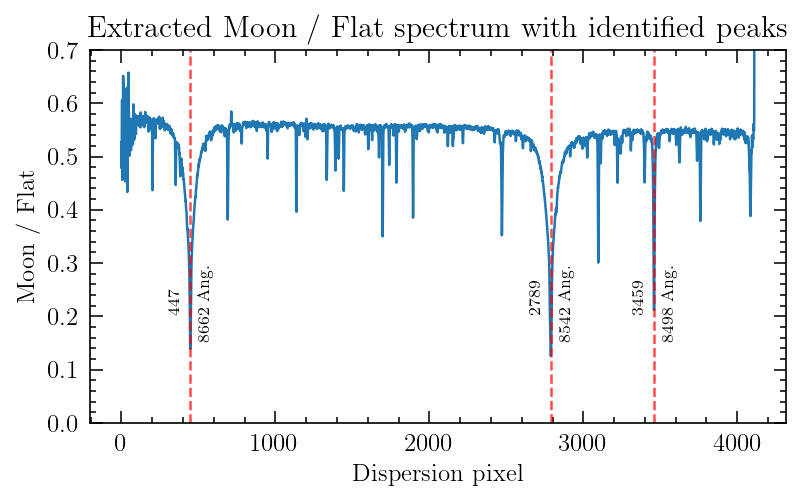

In [58]:
peaks, properties = find_peaks(ratio_smooth2, height=0.18)
print("Identified peaks (pixels):", peaks)
plt.plot(y_pix, ratio)
for peak in peaks:
    plt.axvline(peak, color='red', linestyle='--', alpha=0.7)
plt.xlabel("Dispersion pixel")
plt.ylabel("Moon / Flat")
plt.title("Extracted Moon / Flat spectrum with identified peaks")
plt.ylim(0, 0.7)
# text labels for each peak
lambda_peaks = ["8662 Ang.", "8542 Ang.", "8498 Ang."]
for peak in range(len(peaks)):
    plt.text(peaks[peak]-100, 0.20, f"{peaks[peak]}", rotation=90, verticalalignment='bottom', horizontalalignment='center', fontsize=8)
    plt.text(peaks[peak]+100, 0.15, f"{lambda_peaks[peak]}", rotation=90, verticalalignment='bottom', horizontalalignment='center', fontsize=8)
plt.tight_layout()
plt.savefig("figures/caii_peaks.pdf", dpi=300)
plt.show()

The peaks at pixels 2789 and 3459 are closer together, so these correspond to the Ca II lines at 8542 Angstroms and 8498 Angstroms, respectively. The other line (~3 times separation) at pixel 448 is the Ca II line at 8662 Angstroms.

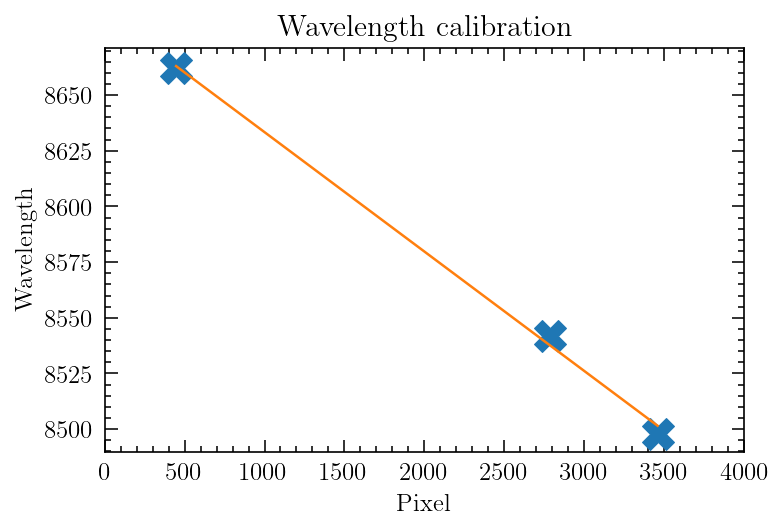

In [38]:
# Wavelength calibration using the identified peaks
# lambda = m * pixel + c

pixels = peaks
wavelengths = np.array([8662, 8542, 8498])

# Fit a linear function to the data
p = np.polyfit(pixels, wavelengths, 1)
m, c = p

plt.plot(pixels, wavelengths, 'X', markersize=15)
plt.plot(pixels, m * pixels + c, '-')
plt.xlim(0, 4000)
plt.xlabel('Pixel')
plt.ylabel('Wavelength')
plt.title('Wavelength calibration')
plt.show()

Note that this attempt at calibrating the pixel-wavelength scale isn't perfect.

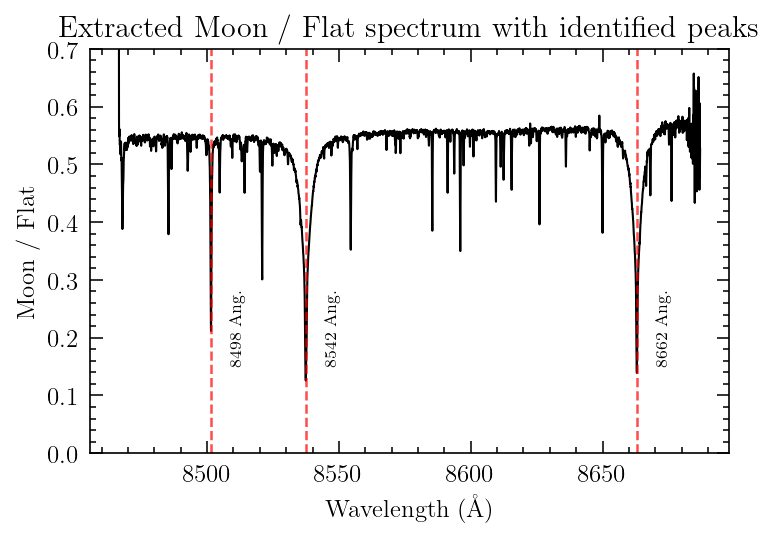

In [57]:
# plot in terms of wavelength
wavelengths_full = m * y_pix + c
plt.plot(wavelengths_full, ratio, lw=1, color='black')
peaks_full = m * peaks + c
for peak in peaks_full:
    plt.axvline(peak, color='red', linestyle='--', alpha=0.7)
plt.xlabel("Wavelength (Å)")
for p in range(len(peaks_full)):
    plt.text(peaks_full[p]+10, 0.15, f"{lambda_peaks[p]}", rotation=90, verticalalignment='bottom', horizontalalignment='center', fontsize=8)
plt.ylabel("Moon / Flat")
plt.title("Extracted Moon / Flat spectrum with identified peaks")
plt.ylim(0, 0.7)
plt.savefig("figures/caii_peaks_lambda.pdf", dpi=300)
plt.show()